## BIRD vs BlueSTARR

### data exploration

In [32]:
import pandas as pd


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions_v1.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)

input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)

predictions

,variantID,window,pos,ref,allele,allele_type,prediction
0,chr1@169611479,chr1:169611328-169611628,pos=169611479,ref=T,T,ref,-0.096332
1,chr1@169611479,chr1:169611328-169611628,pos=169611479,ref=T,C,alt,-0.082146
2,chr1@4120578,chr1:4120427-4120727,pos=4120578,ref=T,T,ref,-0.048179
3,chr1@4120578,chr1:4120427-4120727,pos=4120578,ref=T,C,alt,-0.064989
4,chr1@54715546,chr1:54715395-54715695,pos=54715546,ref=C,C,ref,-0.059572
...,...,...,...,...,...,...,...
685485,chr22@42686472,chr22:42686321-42686621,pos=42686472,ref=G,C,alt,0.216058
685486,chr22@25753842,chr22:25753691-25753991,pos=25753842,ref=G,G,ref,0.245411
685487,chr22@25753842,chr22:25753691-25753991,pos=25753842,ref=G,A,alt,0.232674
685488,chr22@36529459,chr22:36529308-36529608,pos=36529459,ref=C,C,ref,0.493758


In [33]:
bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')

bird_counts[(bird_counts['p-reg']<0.3) & (bird_counts['sum_output']>50)]

,variantID,theta,lowerCI,upperCI,p-reg,ref,alt,output3_ref,output3_alt,output2_ref,...,output1_ref,output1_alt,input3_ref,input3_alt,input2_ref,input2_alt,input1_ref,input1_alt,sum_output,sum_input
0,chr1@169611479,0.970021,0.515223,1.44216,0.185,T,C,30,10,29,...,48,3,23,5,19,4,18,2,124,71
2,chr1@54715546,1.036010,0.683889,2.26155,0.264,C,A,29,3,26,...,27,4,39,0,38,3,23,3,91,106
8,chr1@41902204,1.009840,0.615032,1.81321,0.155,C,T,37,4,27,...,48,6,28,4,33,2,28,1,124,96
9,chr1@25569530,0.993991,0.621267,1.53276,0.143,A,G,12,23,3,...,6,34,6,27,8,23,3,20,97,87
10,chr1@51379106,0.985421,0.467731,1.68631,0.196,G,C,1,18,1,...,5,39,0,19,2,29,1,10,92,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342751,chr22@26860625,1.044770,0.658658,1.88651,0.216,T,C,26,18,24,...,30,20,16,8,11,5,15,7,128,62
342752,chr22@32122143,1.049750,0.708258,2.96895,0.292,C,T,2,28,1,...,0,24,2,38,3,39,3,32,68,117
342753,chr22@33052666,0.993895,0.558812,1.61425,0.143,T,C,16,0,11,...,20,5,24,8,28,2,11,6,58,79
342756,chr22@25753842,1.003320,0.657668,1.49335,0.131,G,A,18,7,27,...,27,1,30,7,40,3,22,4,84,106


In [35]:
y_true = np.where(df["p-reg"] > 0.9, 1, np.where((df["p-reg"]<0.3) & (df['sum_input']>10), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

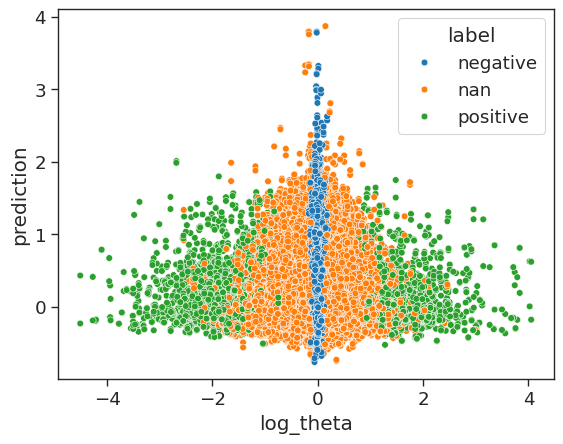

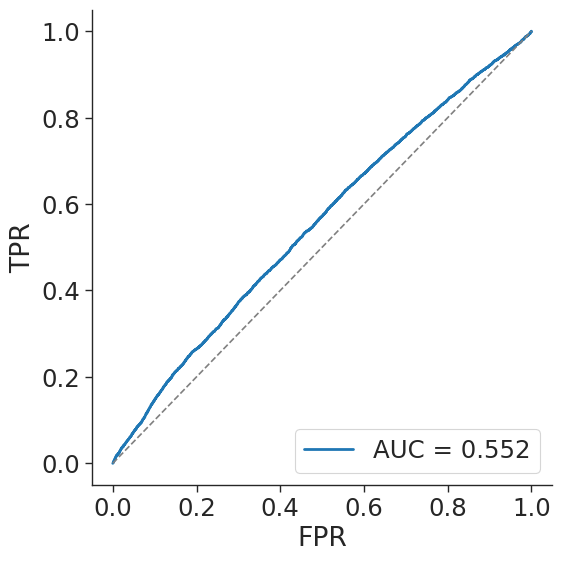

AUC: 0.5520  |  N=457594 (positives=5250.0, negatives=452344.0)


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=2)
%matplotlib inline

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right")
plt.tight_layout()
sns.despine()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")

In [ ]:
### Did not save iterations where 
### 1. preg>0.9 as positive, preg<0.3 and input_counts_sum<100
### 2. preg>0.9 as positive, preg<0.1 and input_counts_sum<100

## DON'T USE THIS - Uses a previous version of the BlueSTARR prediction data

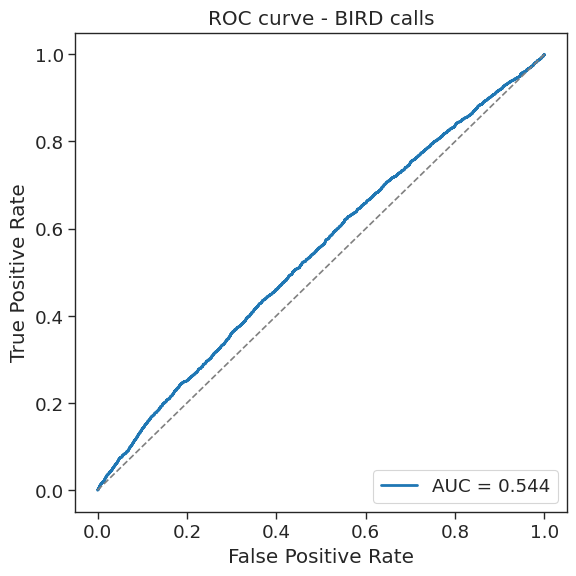

AUC: 0.5440  |  N=228521 (positives=2625.0, negatives=225896.0)


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=1.5)
%matplotlib inline


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)



input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)


bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')
df = bird_counts.merge(predictions, on='variantID', how='inner')

# df['log_theta'] = np.log2(df['theta'])
# df['label'] = np.where(df["p-reg"] > 0.9, 'positive', np.where(df["p-reg"] < 0.3, 'negative', np.nan))

y_true = np.where(df["p-reg"] > 0.9, 1, np.where((df["p-reg"]<0.3) & (df['sum_output']>20), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve - BIRD calls")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")

# RIGHT Version of the BlueSTARR data - USE THIS

In [38]:
!head /hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions_v1.tsv

ID	window	pos	ref	allele	allele_type	prediction
chr1@169611479	chr1:169611328-169611628	pos=169611479	ref=T	T	ref	-0.09633157402276993
chr1@169611479	chr1:169611328-169611628	pos=169611479	ref=T	C	alt	-0.08214619755744934
chr1@4120578	chr1:4120427-4120727	pos=4120578	ref=T	T	ref	-0.04817876219749451
chr1@4120578	chr1:4120427-4120727	pos=4120578	ref=T	C	alt	-0.0649891346693039
chr1@54715546	chr1:54715395-54715695	pos=54715546	ref=C	C	ref	-0.059572234749794006
chr1@54715546	chr1:54715395-54715695	pos=54715546	ref=C	A	alt	-0.09851212799549103
chr1@10948665	chr1:10948514-10948814	pos=10948665	ref=G	G	ref	0.14527086913585663
chr1@10948665	chr1:10948514-10948814	pos=10948665	ref=G	A	alt	0.14109186828136444
chr1@112394506	chr1:112394355-112394655	pos=112394506	ref=T	T	ref	-0.18110297620296478


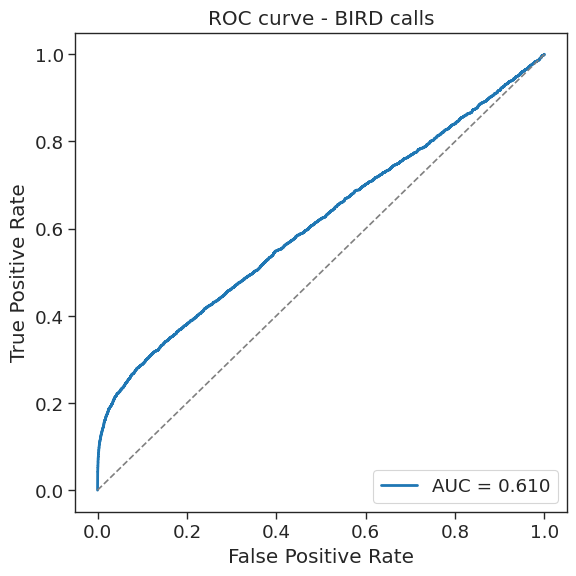

AUC: 0.6102  |  N=228171 (positives=2625.0, negatives=225546.0)


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=1.5)
%matplotlib inline


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions_v1.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)

pivot = predictions.pivot_table(index="variantID", columns="allele_type", values="prediction").reset_index()
pivot["prediction"] = np.abs(pivot["alt"] - pivot["ref"])
# pivot_v1 = pivot[(pivot['prediction']<-0.1) | (pivot['prediction']>0.1)]

input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)

bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')
df = bird_counts.merge(pivot, on='variantID', how='inner')


# # df['log_theta'] = np.log2(df['theta'])
# # df['label'] = np.where(df["p-reg"] > 0.9, 'positive', np.where(df["p-reg"] < 0.3, 'negative', np.nan))

y_true = np.where((df["p-reg"] > 0.9), 1, np.where((df["p-reg"]<0.3) & (df['sum_input']>20), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve - BIRD calls")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")

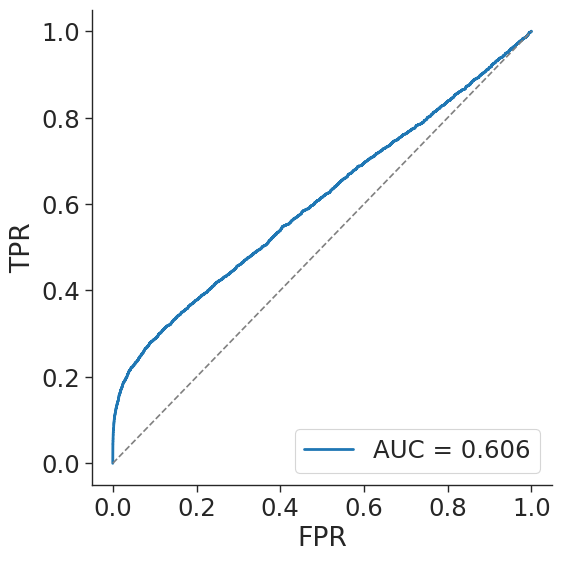

AUC: 0.6060  |  N=203980 (positives=2625.0, negatives=201355.0)


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=2)
%matplotlib inline


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions_v1.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)

pivot = predictions.pivot_table(index="variantID", columns="allele_type", values="prediction").reset_index()
pivot["prediction"] = np.abs(pivot["alt"] - pivot["ref"])

input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)

bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')
df = bird_counts.merge(pivot, on='variantID', how='inner')


# # df['log_theta'] = np.log2(df['theta'])
# # df['label'] = np.where(df["p-reg"] > 0.9, 'positive', np.where(df["p-reg"] < 0.3, 'negative', np.nan))

y_true = np.where((df["p-reg"] > 0.9), 1, np.where((df["p-reg"]<0.3) & (df['sum_input']>50), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
# plt.title(f"ROC curve - BIRD calls")
plt.legend(loc="lower right")
plt.tight_layout()
sns.despine()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")

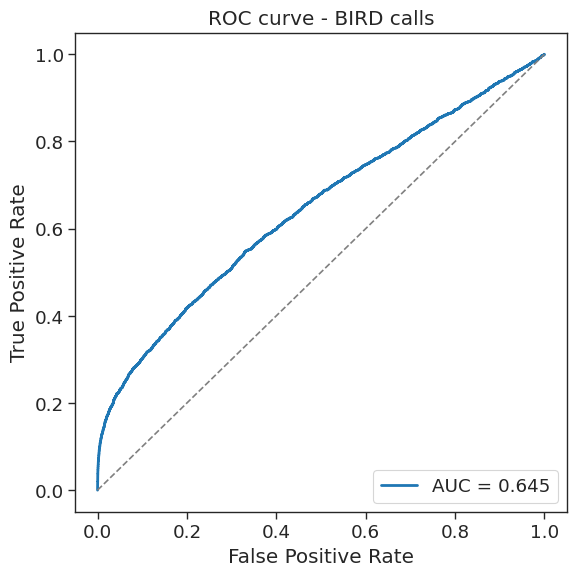

AUC: 0.6446  |  N=25499 (positives=2625.0, negatives=22874.0)


In [3]:
## WRONG

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=1.5)
%matplotlib inline


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/group/igvf/revathy/Blueplots/predictions/K562_MSELoss_bird_predictions_v1.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)

pivot = predictions.pivot_table(index="variantID", columns="allele_type", values="prediction").reset_index()
pivot["prediction"] = np.abs(pivot["alt"] - pivot["ref"])

input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)

bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')
df = bird_counts.merge(pivot, on='variantID', how='inner')


# # df['log_theta'] = np.log2(df['theta'])
# # df['label'] = np.where(df["p-reg"] > 0.9, 'positive', np.where(df["p-reg"] < 0.3, 'negative', np.nan))

y_true = np.where((df["p-reg"] > 0.9) , 1, np.where((df["p-reg"]<0.3) & (df['sum_input']<50), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve - BIRD calls")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")


### BIRD v/s K562 DeepSTARR architecture comparison

Generate predictions for the BIRD variants with the K562 DeepSTARR model and calculate the AUC for BIRD vas DeepSTARR

In [ ]:
#1. Subset the variant IDs from BIRD_alleles.txt file to run it through the prediction script

import pandas as pd

bird = pd.read_csv('/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt', sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
bird[['variantID','ref','alt']].to_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/BIRD_alleles_subset.txt', sep='\t', header=None, index=False)

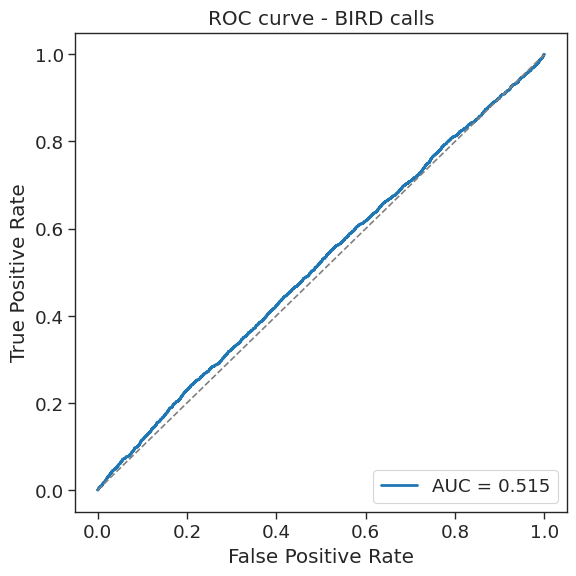

AUC: 0.5154  |  N=203980 (positives=2625.0, negatives=201355.0)


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=1.5)
%matplotlib inline


bird_calls = pd.read_csv("/hpc/group/majoroslab/deepstarr/kari/BIRD-alleles.txt", sep='\t', names=['variantID','theta','lowerCI','upperCI','p-reg','ref','alt'])
input_counts = pd.read_csv('/hpc/home/rv103/igvf/revathy/Blueplots/data/snp_sites.POOL1_K562_mergedPeaks.BIRDcounts.txt', sep='\t')
predictions = pd.read_csv("/hpc/home/rv103/igvf/revathy/Blueplots/predictions/K562_DeepSTARR_BIRD_predictions.tsv", sep='\t')
predictions.rename(columns={'ID':'variantID'}, inplace=True)

input_counts['sum_output'] = input_counts.loc[:, input_counts.columns.str.contains('output')].sum(axis=1)
input_counts['sum_input'] = input_counts.loc[:, input_counts.columns.str.contains('input')].sum(axis=1)
input_counts.rename(columns={'Unnamed: 0':'variantID'}, inplace=True)


bird_counts = bird_calls.merge(input_counts, on='variantID', how='inner')
df = bird_counts.merge(predictions, on='variantID', how='inner')

# df['log_theta'] = np.log2(df['theta'])
# df['label'] = np.where(df["p-reg"] > 0.9, 'positive', np.where(df["p-reg"] < 0.3, 'negative', np.nan))

y_true = np.where(df["p-reg"] > 0.9, 1, np.where((df["p-reg"]<0.3) & (df['sum_input']>50), 0, np.nan))
y_score = df["prediction"].astype(float).values
mask = np.isfinite(y_score) & np.isfinite(y_true)

y_true = y_true[mask]
y_score = y_score[mask]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve - BIRD calls")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}  |  N={len(y_true)} (positives={y_true.sum()}, negatives={(1-y_true).sum()})")

In [ ]:
correlation_df=df[['theta','prediction']]
correlation_df['logtheta'] = np.log2(correlation_df['theta'])
sns.scatterplot(data=correlation_df, x='theta', y='prediction')
plt.show()